# Library Inclusion and Utilities

<!-- structured-notebook -->
## Notebook Summary
Purpose: answer the first research question by constructing weekly cross-platform topic time series and testing whether coverage on one platform tends to lead or lag another using Granger-causality style analyses.

Main steps:
- Prepare harmonized daily and weekly time series for News, PubMed, Reddit, and YouTube topics.
- Visualize topic trends before moving into platform-level causality checks.
- Run topic-level causality tests on active windows and keep diagnostic cells for model checking at the end.


In [ ]:
# structured-notebook-bootstrap
from pathlib import Path
import sys


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists():
            return candidate
    return start


_repo_root = find_repo_root(Path.cwd())
if str(_repo_root) not in sys.path:
    sys.path.append(str(_repo_root))

from src.project_paths import (
    ARXIV_RAW_DIR,
    CHROMA_DIR,
    EXTERNAL_NEWS_DIR,
    GUARDIAN_DATA_DIR,
    LLM_CLASSIFICATION_DIR,
    NEWS_HTML_DIR,
    NEWS_OUTPUT_DIR,
    PREPRINT_RAW_DIR,
    PROQUEST_PROCESSED_DIR,
    PROQUEST_UNPROCESSED_DIR,
    PUBMED_PROCESSED_DIR,
    PUBMED_RAW_DIR,
    PUBLICATIONS_TABLE_DIR,
    REDDIT_DATA_DIR,
    ROOT,
    RQ1_FIGURES_DIR,
    RQ4_PLOTS_DIR,
    TOPIC_MATCHING_DIR,
    YOUTUBE_DATA_DIR,
)


In [1]:
import pandas as pd
import numpy as np
import itables.options as opt
from itables import show
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
from pathlib import Path
import matplotlib.pyplot as plt

from src.news.time_series import *

In [2]:
news_df = pd.read_csv(TOPIC_MATCHING_DIR / 'news_with_topics.csv')
# pubmed_df = pd.read_csv(TOPIC_MATCHING_DIR / 'pubmed_with_topics.csv')
reddit_df = pd.read_csv(TOPIC_MATCHING_DIR / 'reddit_with_topics.csv')
youtube_df = pd.read_csv(TOPIC_MATCHING_DIR / 'youtube_with_topics.csv')
pubmed_df = pd.read_csv(PUBMED_PROCESSED_DIR / 'pubmed_new_articles.csv')

# Data Preparation

In [3]:
# robust numeric parse (coerces bad values to NaN)
for c in ['likes','comments_count','views']:
    youtube_df[c] = (pd.to_numeric(
        youtube_df[c].astype(str).str.replace(',', ''), errors='coerce'
    ))

In [4]:
youtube_df['likes'] = youtube_df['likes'].astype(float)
youtube_df['comments_count'] = youtube_df['comments_count'].astype(float)

youtube_df['engagement']=youtube_df['likes'] + youtube_df['comments_count']
youtube_df['engagement_rate'] = youtube_df['engagement'] / youtube_df['views']
youtube_df.loc[youtube_df['views'] == 0, 'engagement_rate'] = 0

In [5]:
def count_eng_rate():
    df = (youtube_df.groupby(['topic_num', 'date'])['engagement_rate'].sum().reset_index())
    df["source"] = 'Youtube'
    return df
youtube_ts = count_eng_rate()

In [6]:
youtube_ts.rename(columns={'engagement_rate':'count'}, inplace=True)

In [7]:
# rename to a common name for simplicity
news_df = news_df.rename(columns={'Publication date': 'date'})
reddit_df = reddit_df.rename(columns={'ts_utc': 'date'})

# convert all to datetime
for df in [news_df, pubmed_df, reddit_df, youtube_df]:
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.floor("D")

In [8]:
news_ts   = topic_timeseries(news_df, "News")
# pubmed_ts = topic_timeseries(pubmed_df, "PubMed")
reddit_ts = topic_timeseries(reddit_df, "Reddit")
# youtube_ts = topic_timeseries(youtube_df, "Youtube")
pubmed_ts = topic_timeseries(pubmed_df, "PubMed")

# combine
all_ts = pd.concat([news_ts, reddit_ts, youtube_ts, pubmed_ts])

In [9]:
topic_map = (
    youtube_df.groupby("topic_num")["keywords"]
    .unique()
    .apply(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)
    .to_dict()
)
all_ts["topic_name"] = all_ts["topic_num"].map(topic_map)

# Topic Trends visualization

In [10]:
weekly = group_by_date(all_ts, 'W')

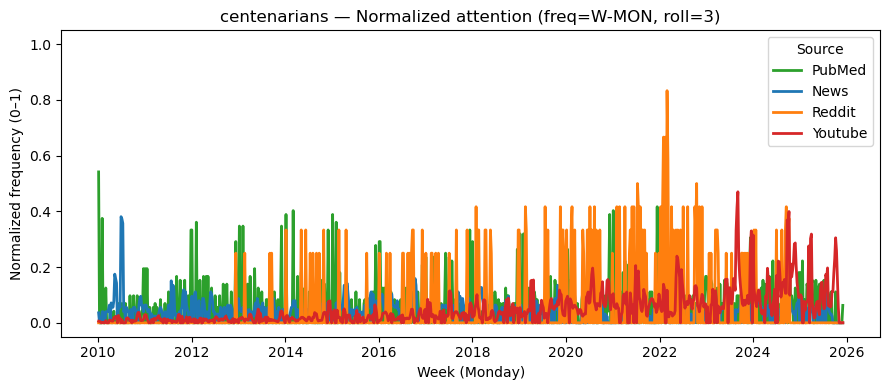

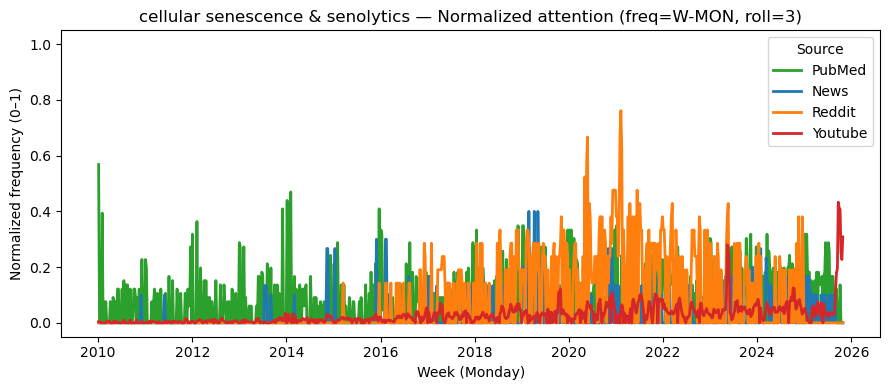

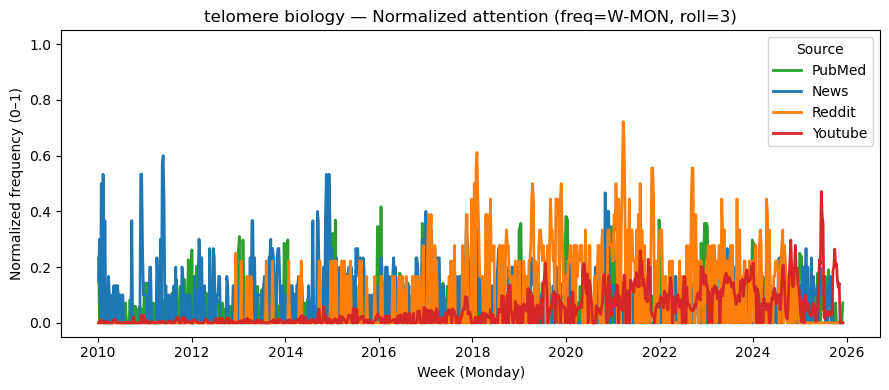

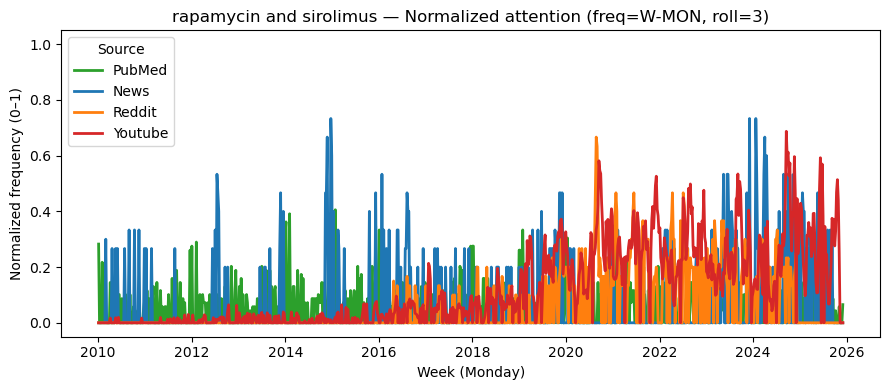

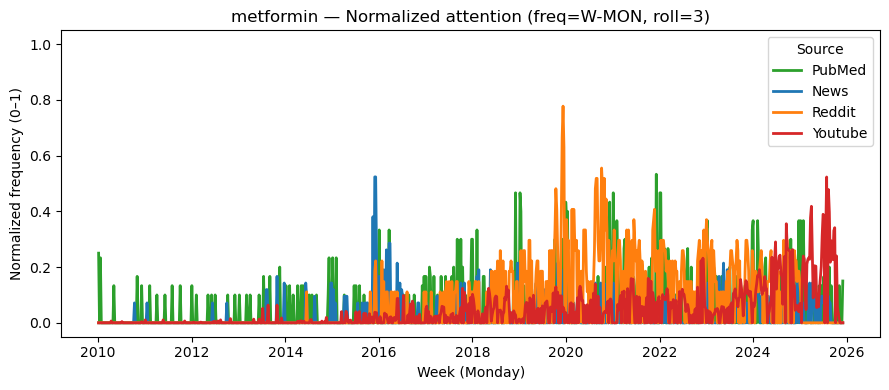

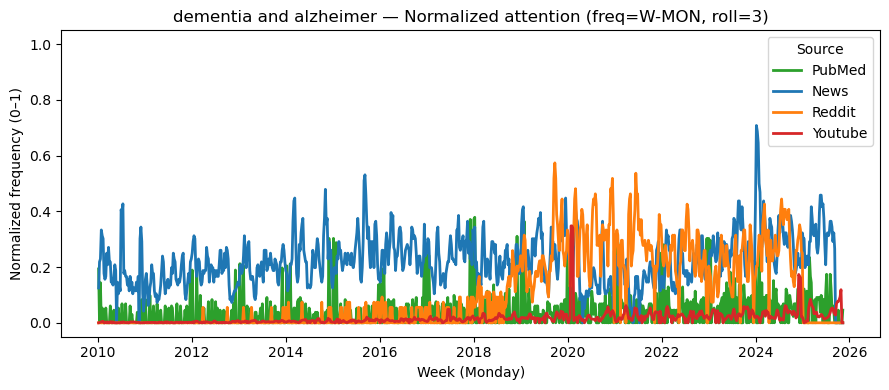

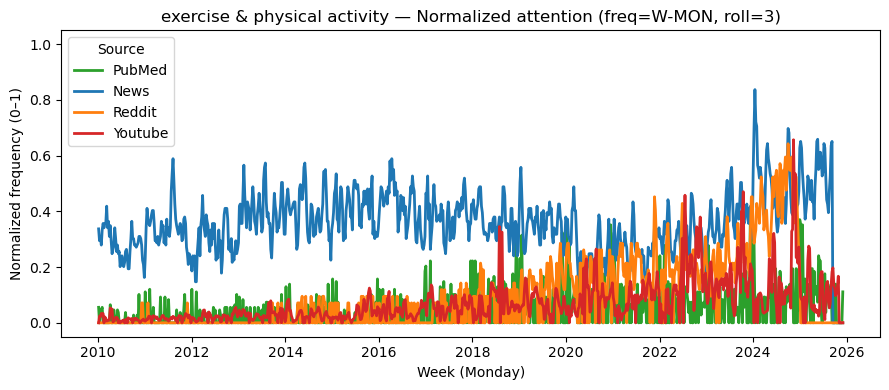

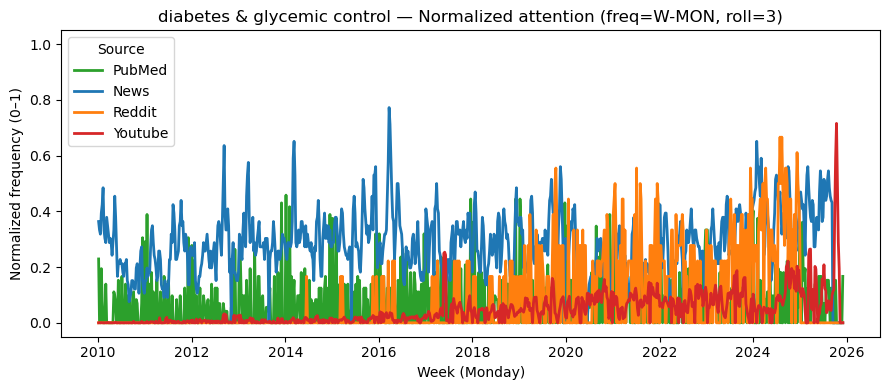

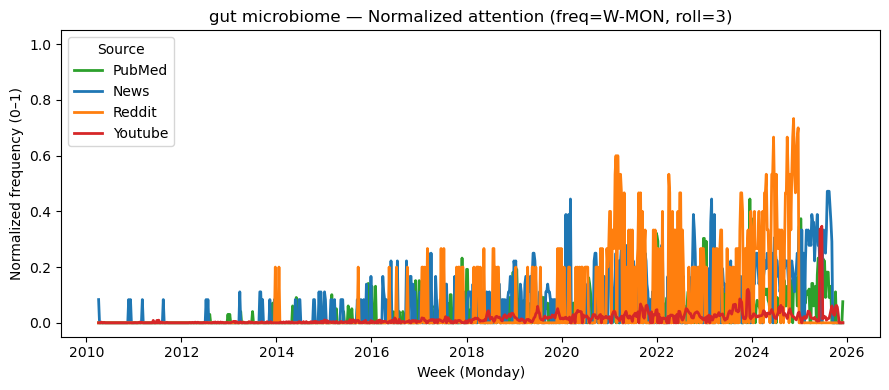

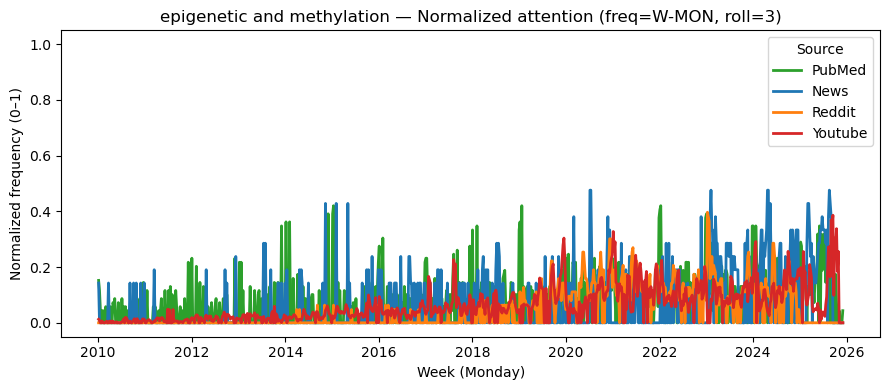

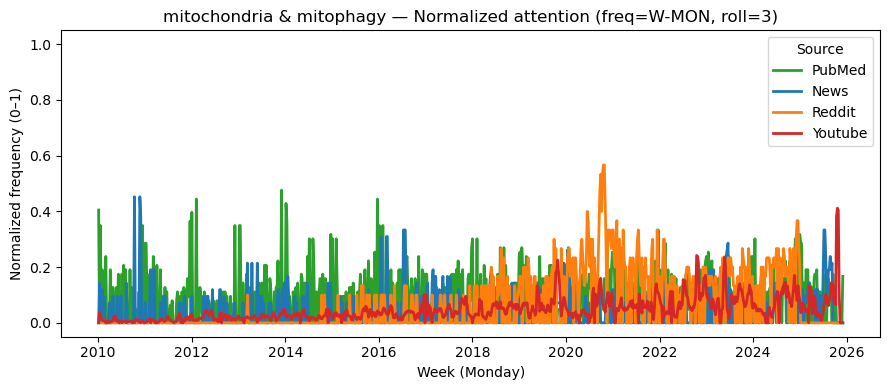

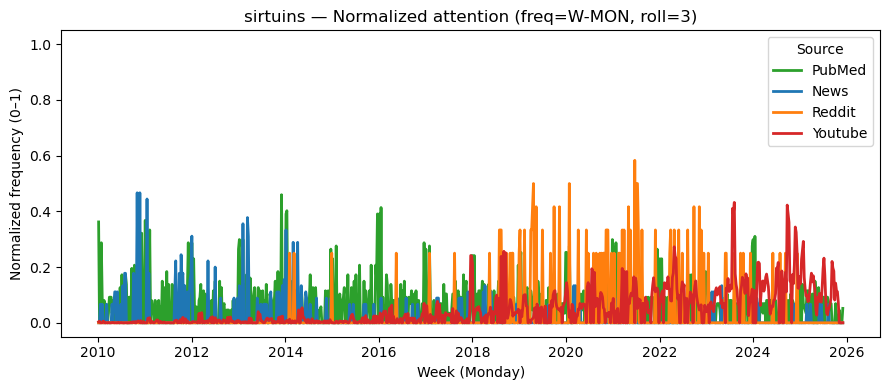

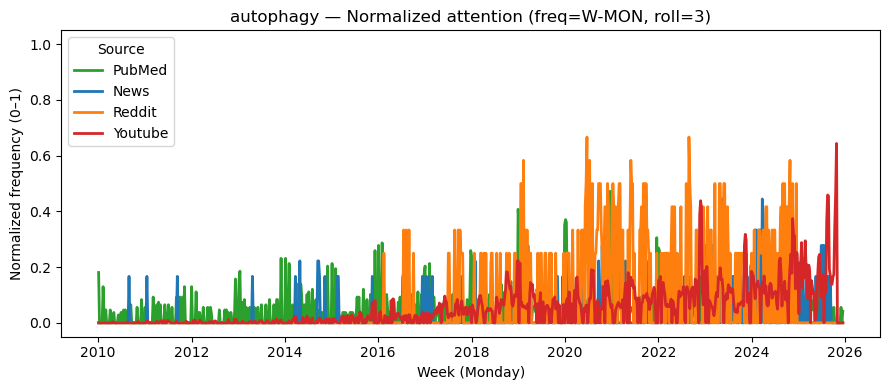

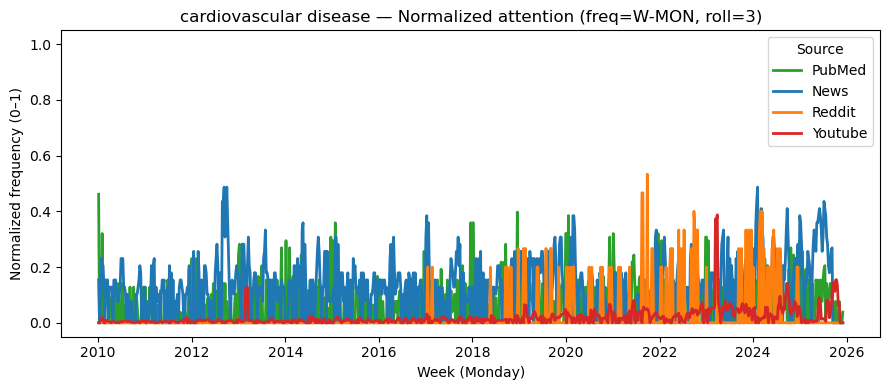

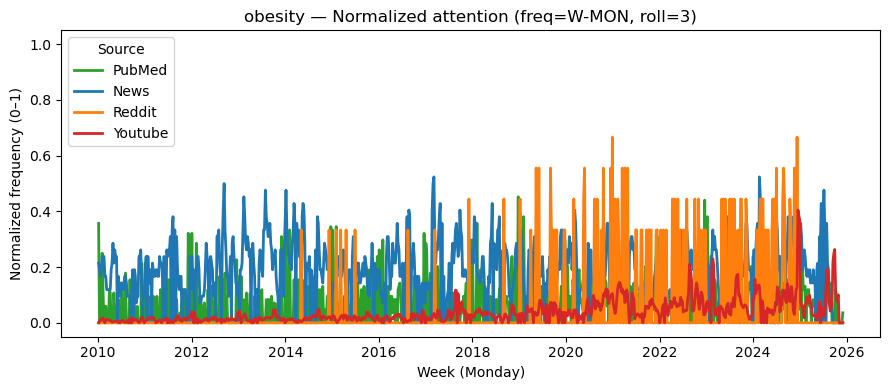

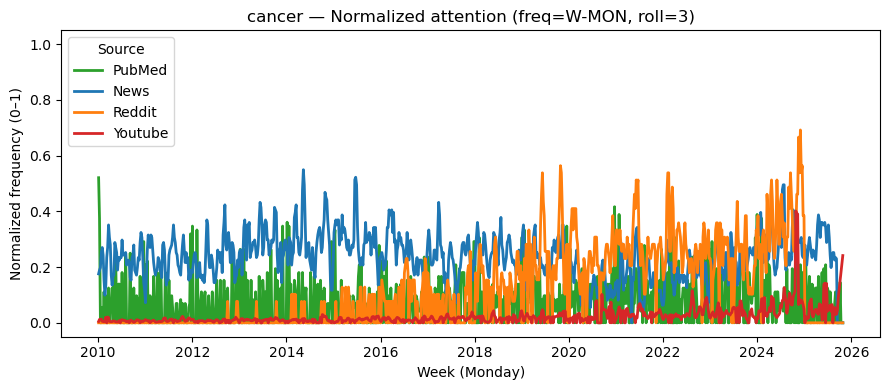

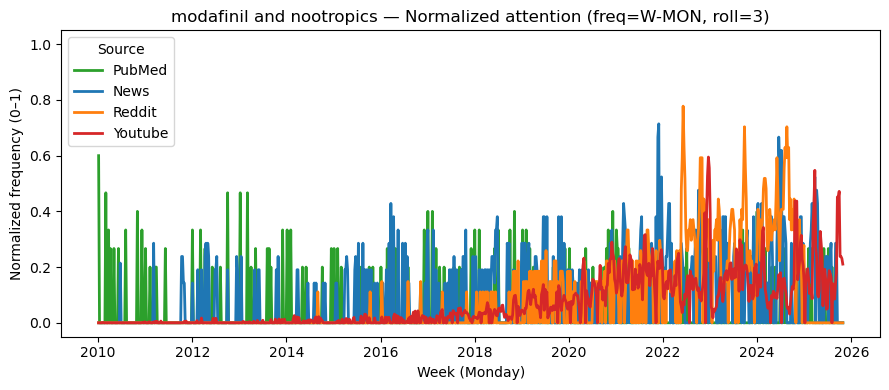

In [11]:
# --- CONFIG ---
FREQ = "W-MON"        # <- match how you created week_mon (weeks ending on Monday)
ROLL = 3              # rolling window (in weeks)
NORMALIZE = True
SAVE_DIR = RQ1_FIGURES_DIR

ALL_SOURCES = ["PubMed", "News", "Reddit", "Youtube"]
PALETTE = {"PubMed":"tab:green", "News":"tab:blue", "Reddit":"tab:orange", "Youtube":"tab:red"}

# 0) Use the weekly frame and standardize the date column name
all_ts = weekly.rename(columns={"week_mon": "date"}).copy()
all_ts["date"] = pd.to_datetime(all_ts["date"])  # already Mondays

# 1) sort + normalize within topic×source (now weekly)
all_ts = all_ts.sort_values(["topic_num", "source", "date"])

if NORMALIZE:
    max_per = all_ts.groupby(["topic_num", "source"])["count"].transform("max")
    all_ts["value"] = (all_ts["count"] / max_per).fillna(0.0)
else:
    all_ts["value"] = all_ts["count"].astype(float)

# 2) rolling (weeks)
if ROLL and ROLL > 1:
    all_ts["value"] = (
        all_ts.groupby(["topic_num", "source"], group_keys=False)["value"]
              .apply(lambda s: s.rolling(ROLL, center=True, min_periods=1).mean())
    )

# 3) plot per topic on a full weekly grid
def plot_topic(t):
    sub = all_ts[all_ts["topic_num"] == t].copy()
    if sub.empty:
        return

    # enforce stable legend/color order
    sub["source"] = pd.Categorical(sub["source"], categories=ALL_SOURCES, ordered=True)

    dmin, dmax = sub["date"].min(), sub["date"].max()
    dates = pd.date_range(dmin, dmax, freq=FREQ)     # weekly Mondays (your labels)

    # ensure one value per (date, source)
    sub_agg = (sub[["date","source","value"]]
               .sort_values(["date","source"])
               .drop_duplicates(["date","source"])
               .set_index(["date","source"])
               .sort_index())

    # rebuild onto full date×source grid (fills missing weeks with 0)
    full_index = pd.MultiIndex.from_product([dates, ALL_SOURCES], names=["date","source"])
    full = sub_agg.reindex(full_index).reset_index()
    full["value"] = full["value"].fillna(0.0)

    # title
    tlabel = (sub["topic_name"].dropna().iloc[0]
              if "topic_name" in sub and sub["topic_name"].notna().any()
              else f"Topic {t}")

    plt.figure(figsize=(9,4))

    # --- DIAGNOSE WHY REDDIT IS INVISIBLE ---
    # sub = all_ts[all_ts["topic_num"] == t].copy()
    
    # # 0) sanity: what source labels do we actually have?
    # print("sources in sub:", sorted(sub["source"].astype(str).unique()))
    
    # # 1) before any reindexing, is Reddit present and nonzero?
    # r = sub.query("source == 'Reddit'")
    # print("reddit rows:", len(r), "reddit sum(count):", r["count"].sum())
    # print("reddit max(count):", r["count"].max())
    
    # # 2) after normalization/rolling, did Reddit collapse to zeros?
    # print("reddit sum(value):", r["value"].sum(), "reddit max(value):", r["value"].max())
    
    # # 3) after building the full grid, are there any nonzero Reddit points?
    # full_reddit = full[full["source"] == "Reddit"]
    # print("full grid reddit nonzero weeks:", (full_reddit["value"] > 0).sum())

    
    sns.lineplot(
        data=full, x="date", y="value",
        hue="source", hue_order=ALL_SOURCES,
        palette=PALETTE, linewidth=2, errorbar=None
    )
    plt.ylim(-0.05, 1.05 if NORMALIZE else None)
    plt.title(f"{tlabel} — {'Normalized ' if NORMALIZE else ''}attention (freq={FREQ}, roll={ROLL})")
    plt.xlabel("Week (Monday)")
    plt.ylabel("Normalized frequency (0–1)" if NORMALIZE else "Document count")
    plt.legend(title="Source")
    plt.tight_layout()

    if SAVE_DIR:
        Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)
        plt.savefig(Path(SAVE_DIR) / f"topic_{t:02d}.png", dpi=180)
    plt.show()

# 4) run
for t in sorted(all_ts["topic_num"].unique()):
    plot_topic(t)


<!-- structured-notebook -->
## Transition To Causality Testing
The notebook moves here from descriptive trend building into inferential analysis. The next blocks first test aggregate platform relationships, then narrow the same logic to shared topics.


# Granger Causality

## Overall Platform Causation

***
News-PubMed
***

In [372]:
out = create_ts_df(weekly, ['News', 'NewPubMed'], -1)

General causation (not limited by topic) shows the following numbers:<br>
News → PubMed<br>
(np.int64(1), np.float64(0.39366522873196974)) best (lag, p)<br>
PubMed → News<br>
(np.int64(1), np.float64(0.3353590134328095)) best (lag, p)

**Conclusion:** Even though the 2 platform corpuses are built on the same query. It is not possible to see any impact without limiting to topics.

In [374]:
week_mon = news_df['date'].dt.to_period('W-MON').dt.end_time.dt.normalize()

news_weekly = (
    news_df.assign(week_mon=week_mon)
           .groupby('week_mon', as_index=False)
           .size()                      # counts rows
           .rename(columns={'size':'News_count'})
)

pubmed_weekly = (
    new_pubmed_df.assign(week_mon=new_pubmed_df['date'].dt.to_period('W-MON').dt.end_time.dt.normalize())
             .groupby('week_mon', as_index=False)
             .size()
             .rename(columns={'size':'NewPubMed_count'})
)

out = (news_weekly
       .merge(pubmed_weekly, on='week_mon', how='outer', validate='one_to_one')
       .sort_values('week_mon')
       .fillna(0))


In [378]:
check_causality(out, ["News_count", "NewPubMed_count"], 12)

NewPubMed_count → News_count
(np.int64(1), np.float64(0.8917197660740757)) best (lag, p)
News_count → NewPubMed_count
(np.int64(1), np.float64(0.4970580969925873)) best (lag, p)


/home/iskender/anaconda3/envs/bertopic-env/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/iskender/anaconda3/envs/bertopic-env/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


***
News-Youtube
***

General causation (not limited by topic) shows the following numbers:<br>
Youtube_count → News_count<br>
(np.int64(1), np.float64(0.7683105557875839)) best (lag, p)<br>
News_count → Youtube_count<br>
(np.int64(1), np.float64(0.33289217055783715)) best (lag, p)<br>

**Conclusion**: The same conclusion.

In [269]:
week_mon = news_df['date'].dt.to_period('W-MON').dt.end_time.dt.normalize()

news_weekly = (
    news_df.assign(week_mon=week_mon)
           .groupby('week_mon', as_index=False)
           .size()                      # counts rows
           .rename(columns={'size':'News_count'})
)

yt_weekly = (
    youtube_df.assign(week_mon=youtube_df['date'].dt.to_period('W-MON').dt.end_time.dt.normalize())
             .groupby('week_mon', as_index=False)
             .size()
             .rename(columns={'size':'Youtube_count'})
)

out = (news_weekly
       .merge(yt_weekly, on='week_mon', how='outer', validate='one_to_one')
       .sort_values('week_mon')
       .fillna(0))


In [271]:
check_causality(out, ["News_count", "Youtube_count"], 12)

Youtube_count → News_count
(np.int64(1), np.float64(0.7683105557875839)) best (lag, p)
News_count → Youtube_count
(np.int64(1), np.float64(0.33289217055783715)) best (lag, p)


/home/iskender/anaconda3/envs/bertopic-env/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/iskender/anaconda3/envs/bertopic-env/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


***
News-Reddit
***

In [281]:
week_mon = news_df['date'].dt.to_period('W-MON').dt.end_time.dt.normalize()

news_weekly = (
    news_df.assign(week_mon=week_mon)
           .groupby('week_mon', as_index=False)
           .size()                      # counts rows
           .rename(columns={'size':'News_count'})
)

reddit_weekly = (
    reddit_df.assign(week_mon=reddit_df['date'].dt.to_period('W-MON').dt.end_time.dt.normalize())
             .groupby('week_mon', as_index=False)
             .size()
             .rename(columns={'size':'Reddit_count'})
)

out = (news_weekly
       .merge(reddit_weekly, on='week_mon', how='outer', validate='one_to_one')
       .sort_values('week_mon')
       .fillna(0))


/tmp/ipykernel_13690/2901435775.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  reddit_df.assign(week_mon=reddit_df['date'].dt.to_period('W-MON').dt.end_time.dt.normalize())


In [282]:
check_causality(out, ["News_count", "Reddit_count"], 12)

Reddit_count → News_count
(np.int64(1), np.float64(0.10660359974033089)) best (lag, p)
News_count → Reddit_count
(np.int64(1), np.float64(0.3807450686013478)) best (lag, p)


/home/iskender/anaconda3/envs/bertopic-env/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/iskender/anaconda3/envs/bertopic-env/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


***
PubMed - Youtube
***

In [285]:
pubmed_weekly = (
    pubmed_df.assign(week_mon=pubmed_df['date'].dt.to_period('W-MON').dt.end_time.dt.normalize())
             .groupby('week_mon', as_index=False)
             .size()
             .rename(columns={'size':'PubMed_count'})
)

youtube_weekly = (
    youtube_df.assign(week_mon=youtube_df['date'].dt.to_period('W-MON').dt.end_time.dt.normalize())
             .groupby('week_mon', as_index=False)
             .size()
             .rename(columns={'size':'Youtube_count'})
)

out = (pubmed_weekly
       .merge(youtube_weekly, on='week_mon', how='outer', validate='one_to_one')
       .sort_values('week_mon')
       .fillna(0))


In [286]:
check_causality(out, ["Youtube_count", "PubMed_count"], 12)

PubMed_count → Youtube_count
(np.int64(1), np.float64(0.5962891553515206)) best (lag, p)
Youtube_count → PubMed_count
(np.int64(1), np.float64(0.4949783019894034)) best (lag, p)


/home/iskender/anaconda3/envs/bertopic-env/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/iskender/anaconda3/envs/bertopic-env/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


***
PubMed - Reddit
***

In [287]:
pubmed_weekly = (
    pubmed_df.assign(week_mon=pubmed_df['date'].dt.to_period('W-MON').dt.end_time.dt.normalize())
             .groupby('week_mon', as_index=False)
             .size()
             .rename(columns={'size':'PubMed_count'})
)

reddit_weekly = (
    reddit_df.assign(week_mon=reddit_df['date'].dt.to_period('W-MON').dt.end_time.dt.normalize())
             .groupby('week_mon', as_index=False)
             .size()
             .rename(columns={'size':'Reddit_count'})
)
out = (pubmed_weekly
       .merge(reddit_weekly, on='week_mon', how='outer', validate='one_to_one')
       .sort_values('week_mon')
       .fillna(0))

/tmp/ipykernel_13690/276792411.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  reddit_df.assign(week_mon=reddit_df['date'].dt.to_period('W-MON').dt.end_time.dt.normalize())


In [288]:
check_causality(out, ["Reddit_count", "PubMed_count"], 12)

PubMed_count → Reddit_count
(np.int64(1), np.float64(0.5665401206768725)) best (lag, p)
Reddit_count → PubMed_count
(np.int64(1), np.float64(0.8158687127354893)) best (lag, p)


/home/iskender/anaconda3/envs/bertopic-env/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/iskender/anaconda3/envs/bertopic-env/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


***
Youtube-Reddit
***

In [289]:
youtube_weekly = (
    youtube_df.assign(week_mon=youtube_df['date'].dt.to_period('W-MON').dt.end_time.dt.normalize())
             .groupby('week_mon', as_index=False)
             .size()
             .rename(columns={'size':'Youtube_count'})
)

reddit_weekly = (
    reddit_df.assign(week_mon=reddit_df['date'].dt.to_period('W-MON').dt.end_time.dt.normalize())
             .groupby('week_mon', as_index=False)
             .size()
             .rename(columns={'size':'Reddit_count'})
)
out = (youtube_weekly
       .merge(reddit_weekly, on='week_mon', how='outer', validate='one_to_one')
       .sort_values('week_mon')
       .fillna(0))

/tmp/ipykernel_13690/3672203140.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  reddit_df.assign(week_mon=reddit_df['date'].dt.to_period('W-MON').dt.end_time.dt.normalize())


In [290]:
check_causality(out, ["Youtube_count", "Reddit_count"], 12)

Reddit_count → Youtube_count
(np.int64(1), np.float64(0.18266024982739165)) best (lag, p)
Youtube_count → Reddit_count
(np.int64(1), np.float64(0.5296556955121237)) best (lag, p)


/home/iskender/anaconda3/envs/bertopic-env/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/iskender/anaconda3/envs/bertopic-env/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


<!-- structured-notebook -->
## Topic-Level Testing Note
From this point onward the analysis trims each pair of time series to windows where both sources are active, which helps reduce spurious results from sparse early periods or one-sided topic coverage.


## Topic-Based Causation

In [12]:
def bounds_both_active(df, cols, window=8, min_nonzero_weeks=3):
    """
    Return (i0, i1) indices that bound the period where *each* series
    has at least `min_nonzero_weeks` non-zero observations within any
    rolling window of length `window`. If a series never gets active,
    return (None, None).
    """
    idx = df.index

    starts, ends = [], []
    for c in cols:
        nz = (df[c] > 0).astype(int)
        roll = nz.rolling(window, min_periods=1).sum()
        active = roll >= min_nonzero_weeks
        if not active.any():
            return None, None
        # first/last True
        i0 = active.idxmax()
        i1 = active[::-1].idxmax()  # last True
        starts.append(i0)
        ends.append(i1)

    start = max(starts)
    end   = min(ends)
    if start > end:
        return None, None
    return start, end

def trim_to_both_active(df, cols=("News_count","Youtube_count"),
                        window=8, min_nonzero_weeks=3):
    """
    Trim leading/trailing weeks so the kept region is after both series
    show sustained activity; keep interior zeros.
    """
    df = df.sort_values("week_mon").set_index("week_mon")
    i0, i1 = bounds_both_active(df, cols, window, min_nonzero_weeks)
    if i0 is None:
        # nothing sustained — return empty frame
        return df.iloc[0:0].reset_index()
    out = df.loc[i0:i1].copy()
    return out.reset_index()


In [13]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="verbose is deprecated",
    category=FutureWarning,
    module="statsmodels"
)

### News-PubMed

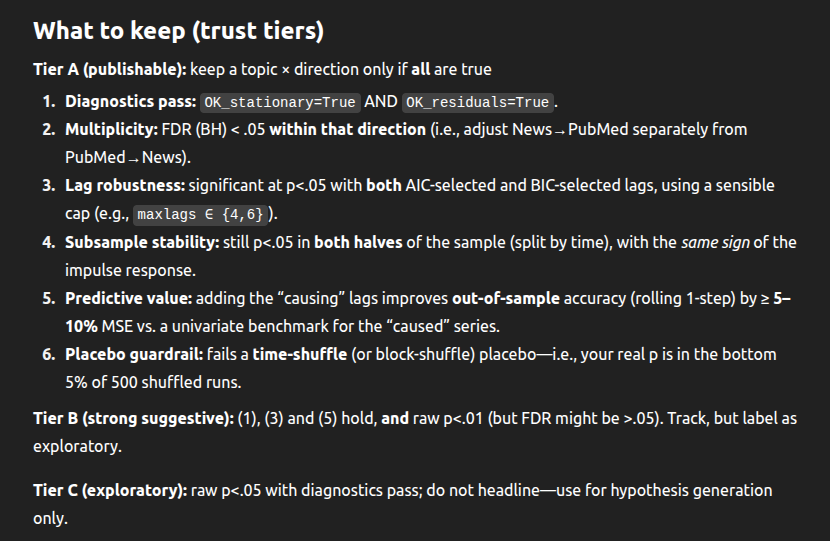

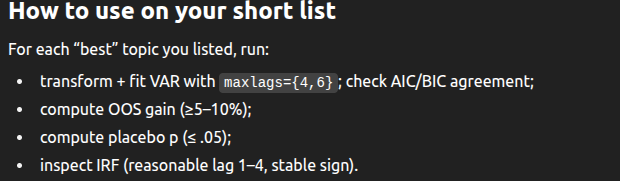

In [14]:
def var_granger_one(Z, caused, causing, maxlags=6, ic='aic'):
    from statsmodels.tsa.api import VAR
    p = max(1, min(maxlags, len(Z)//5))
    sel = VAR(Z).select_order(maxlags=p).selected_orders[ic]
    sel = int(max(1, sel))
    m = VAR(Z).fit(sel)
    test = m.test_causality(caused=caused, causing=[causing], kind='f')
    return {'p': float(test.pvalue), 'F': float(test.test_statistic), 'lag': sel, 'model': m}

In [31]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import numpy as np
from statsmodels.tsa.api import VAR

def lb_min_p(model):
    T = model.resid.shape[0]
    L = max(2, min(8, T // 6))
    pmins = []
    for j in range(model.resid.shape[1]):
        pvals = acorr_ljungbox(model.resid.iloc[:, j], lags=L, return_df=True)["lb_pvalue"]
        pmins.append(float(pvals.min()))
    return float(np.nanmin(pmins))

def run_gc_test(grouped_ts:pd.DataFrame, caused, causing, maxlags:int = 12):
    for topic in range(17):
        print(topic)
        out = create_ts_df(weekly, [caused, causing], topic)  # keep order fixed
        out = trim_to_both_active(out, cols=[caused, causing],
                                  window=8, min_nonzero_weeks=3)
        out = out.sort_values("week_mon").copy()
        out["week_mon"] = pd.to_datetime(out["week_mon"])
        out = out.set_index(pd.PeriodIndex(out["week_mon"], freq="W-MON"))
    
        print(len(out))
    
        # stationarize
        Z = np.log1p(out[[caused, causing]]).diff().dropna().asfreq("W-MON")
        if len(Z) < 30:
            print(len(Z), "→ too short after diff; skip\n")
            continue
    
        res_aic = var_granger_one(Z, caused, causing, maxlags=maxlags, ic='aic')
        res_bic = var_granger_one(Z, caused, causing, maxlags=maxlags, ic='bic')
    
        # decide with BIC only (parsimonious) — adjust if you prefer
        agree = (res_aic['p'] < 0.05) and (res_bic['p'] < 0.05)
    
        # optional residuals check
        lbp = lb_min_p(res_bic['model'])
    
        print(f"AIC: p={res_aic['p']:.4g}, F={res_aic['F']:.3f}, lag={res_aic['lag']}, "
              f"BIC: p={res_bic['p']:.4g}, F={res_bic['F']:.3f}, lag={res_bic['lag']}, "
              f"LB_min_p={lbp:.3g}, keep={agree and (lbp>0.05)}\n")

In [34]:
run_gc_test(weekly, "News", "PubMed", 12)

0
804
AIC: p=0.2442, F=1.248, lag=12, BIC: p=0.2442, F=1.248, lag=12, LB_min_p=0.776, keep=False

1
614
AIC: p=0.9811, F=0.343, lag=12, BIC: p=0.9682, F=0.294, lag=8, LB_min_p=0.0948, keep=False

2
746
AIC: p=0.4017, F=1.048, lag=12, BIC: p=0.1227, F=1.591, lag=8, LB_min_p=0.0249, keep=False

3
679
AIC: p=0.7485, F=0.704, lag=12, BIC: p=0.3327, F=1.148, lag=5, LB_min_p=8.65e-07, keep=False

4
531
AIC: p=0.7259, F=0.727, lag=12, BIC: p=0.6878, F=0.705, lag=8, LB_min_p=0.246, keep=False

5
820
AIC: p=0.2826, F=1.192, lag=12, BIC: p=0.2826, F=1.192, lag=12, LB_min_p=0.528, keep=False

6
821
AIC: p=0.03859, F=1.832, lag=12, BIC: p=0.03859, F=1.832, lag=12, LB_min_p=0.427, keep=True

7
819
AIC: p=0.769, F=0.683, lag=12, BIC: p=0.769, F=0.683, lag=12, LB_min_p=0.685, keep=False

8
512
AIC: p=0.1683, F=1.382, lag=12, BIC: p=0.1649, F=1.628, lag=4, LB_min_p=0.00019, keep=False

9
747
AIC: p=0.03361, F=1.872, lag=12, BIC: p=0.07133, F=1.808, lag=8, LB_min_p=0.119, keep=False

10
808
AIC: p=0.03

In [21]:
for topic in range(16+1):
    print(topic)
    out = create_ts_df(weekly, ['News', 'PubMed'], topic)
    out = trim_to_both_active(out, cols=["News","PubMed"],
                               window=8, min_nonzero_weeks=3)
    print(len(out))
    check_causality(out, ["News", "PubMed"], 12)
    print("\n")

0
804
News → PubMed: best lag=1, F=2.4576, p=0.1174
PubMed → News: best lag=11, F=1.4288, p=0.1547


1
614
News → PubMed: best lag=5, F=2.7552, p=0.01797
PubMed → News: best lag=1, F=0.3215, p=0.5709


2
746
News → PubMed: best lag=1, F=7.0895, p=0.007922
PubMed → News: best lag=1, F=5.3183, p=0.02138


3
679
News → PubMed: best lag=1, F=4.6651, p=0.03113
PubMed → News: best lag=6, F=1.5089, p=0.1725


4
531
News → PubMed: best lag=8, F=1.6950, p=0.09697
PubMed → News: best lag=1, F=0.6523, p=0.4197


5
820
News → PubMed: best lag=12, F=1.5124, p=0.114
PubMed → News: best lag=2, F=1.6430, p=0.194


6
821
News → PubMed: best lag=3, F=0.8509, p=0.4663
PubMed → News: best lag=9, F=2.3472, p=0.01292


7
819
News → PubMed: best lag=3, F=0.8558, p=0.4637
PubMed → News: best lag=1, F=0.3111, p=0.5772


8
512
News → PubMed: best lag=3, F=4.0021, p=0.007818
PubMed → News: best lag=10, F=1.7710, p=0.06333


9
747
News → PubMed: best lag=10, F=1.8659, p=0.04677
PubMed → News: best lag=11, F=2.078

**Conclusion:**<br>
The best News->PubMed topic-relationships:
- Topic 3 with p-value 0.01611
- Topic 5 with p-value 0.01892
- Topic 8 with p-value 0.009307
- Topic 9 with p-value 0.03539
- Topic 13 with p-value 0.0329

The best PubMed->News topic-relationships:
- Topic 0 with p-value 0.03476
- Topic 6 with p-value 0.02689
- Topic 8 with p-value 0.03011 (**bidirectional**)
- Topic 9 with p-value 0.0246 (**bidirectional**)
- Topic 12 with p-value 0.05095
- Topic 13 with p-value 0.012 (**bidirectional**)
- Topic 16 with p-value 0.04784

### News-Youtube

In [35]:
run_gc_test(weekly, "News", "Youtube", 12)

0
806
AIC: p=0.5817, F=0.866, lag=12, BIC: p=0.8799, F=0.399, lag=6, LB_min_p=0.00038, keep=False

1
614
AIC: p=0.4508, F=0.993, lag=11, BIC: p=0.5611, F=0.832, lag=7, LB_min_p=0.00204, keep=False

2
738
AIC: p=0.5907, F=0.857, lag=12, BIC: p=0.7369, F=0.592, lag=6, LB_min_p=0.000361, keep=False

3
677
AIC: p=0.7481, F=0.675, lag=10, BIC: p=0.5233, F=0.837, lag=5, LB_min_p=0.000653, keep=False

4
531
AIC: p=0.1729, F=1.372, lag=12, BIC: p=0.004626, F=3.410, lag=5, LB_min_p=0.000183, keep=False

5
821
AIC: p=0.7828, F=0.654, lag=11, BIC: p=0.676, F=0.667, lag=6, LB_min_p=2.04e-07, keep=False

6
821
AIC: p=0.5239, F=0.909, lag=10, BIC: p=0.7361, F=0.553, lag=5, LB_min_p=0.000267, keep=False

7
765
AIC: p=0.07421, F=1.706, lag=10, BIC: p=0.3211, F=1.167, lag=6, LB_min_p=0.00924, keep=False

8
607
AIC: p=0.1542, F=1.411, lag=12, BIC: p=0.08475, F=1.794, lag=7, LB_min_p=0.00913, keep=False

9
747
AIC: p=0.008174, F=2.392, lag=10, BIC: p=0.01288, F=2.706, lag=6, LB_min_p=0.00266, keep=False


In [46]:
for topic in range(16+1):
    print(topic)
    out = create_ts_df(weekly, ['News', 'Youtube'], topic)
    out = trim_to_both_active(out, cols=["News","Youtube"],
                               window=8, min_nonzero_weeks=3)
    print(len(out))
    check_causality(out, ["News", "Youtube"], 12)
    print("\n")

0
806
News → Youtube: best lag=3, F=0.6775, p=0.5659
Youtube → News: best lag=2, F=0.5707, p=0.5654


1
614
News → Youtube: best lag=3, F=0.9270, p=0.4273
Youtube → News: best lag=9, F=1.2220, p=0.2784


2
738
News → Youtube: best lag=5, F=2.4844, p=0.0304
Youtube → News: best lag=1, F=0.5686, p=0.4511


3
677
News → Youtube: best lag=11, F=1.4079, p=0.1645
Youtube → News: best lag=4, F=1.1187, p=0.3465


4
531
News → Youtube: best lag=7, F=1.9917, p=0.05445
Youtube → News: best lag=5, F=3.4099, p=0.004851


5
821
News → Youtube: best lag=2, F=2.4238, p=0.08922
Youtube → News: best lag=2, F=1.4775, p=0.2288


6
821
News → Youtube: best lag=5, F=1.8340, p=0.1038
Youtube → News: best lag=12, F=1.2505, p=0.2437


7
765
News → Youtube: best lag=9, F=2.1287, p=0.02517
Youtube → News: best lag=10, F=1.7059, p=0.07535


8
607
News → Youtube: best lag=1, F=8.7190, p=0.003272
Youtube → News: best lag=4, F=2.8160, p=0.02464


9
747
News → Youtube: best lag=1, F=0.5391, p=0.463
Youtube → News: be

**Conclusion:**<br>
The best News->Youtube topic-relationships:
- Topic 4 with p-value 0.04652
- Topic 8 with p-value 0.04684
- Topic 12 with p-value 0.01461
- Topic 14 with p-value 0.0424
- Topic 16 with p-value 0.0005958

The best Youtube->News topic-relationships:
- Topic 0 with p-value 0.05763
- Topic 1 with p-value 0.06499
- Topic 3 with p-value 0.03676
- Topic 4 with p-value 0.01478 (**bidirectional**)
- Topic 7 with p-value 0.01351
- Topic 8 with p-value 0.009242 (**bidirectional**)
- Topic 9 with p-value 0.03698
- Topic 15 with p-value 0.01492
- Topic 16 with p-value 0.002077 (**bidirectional**)

### News-Reddit

In [49]:
run_gc_test(weekly,"Reddit", "News", 12)

0
527
AIC: p=0.4588, F=0.975, lag=9, BIC: p=0.7862, F=0.431, lag=4, LB_min_p=0.000726, keep=False

1
454
AIC: p=0.9, F=0.506, lag=11, BIC: p=0.8016, F=0.509, lag=6, LB_min_p=0.00244, keep=False

2
591
AIC: p=0.9218, F=0.426, lag=9, BIC: p=0.9511, F=0.270, lag=6, LB_min_p=4.09e-05, keep=False

3
396
AIC: p=0.9716, F=0.310, lag=9, BIC: p=0.917, F=0.293, lag=5, LB_min_p=0.0181, keep=False

4
440
AIC: p=0.03897, F=1.978, lag=9, BIC: p=0.5274, F=0.797, lag=4, LB_min_p=1.92e-05, keep=False

5
579
AIC: p=0.1963, F=1.371, lag=9, BIC: p=0.006341, F=3.600, lag=4, LB_min_p=3.65e-06, keep=False

6
733
AIC: p=0.782, F=0.638, lag=10, BIC: p=0.6487, F=0.701, lag=6, LB_min_p=0.000929, keep=False

7
465
AIC: p=0.03748, F=1.935, lag=10, BIC: p=0.6628, F=0.684, lag=6, LB_min_p=0.015, keep=False

8
410
AIC: p=0.07054, F=1.949, lag=6, BIC: p=0.1573, F=1.601, lag=5, LB_min_p=0.0351, keep=False

9
449
AIC: p=0.4257, F=1.021, lag=11, BIC: p=0.07367, F=2.143, lag=4, LB_min_p=0.00367, keep=False

10
493
AIC: p=

### Pubmed-Youtube

In [43]:
run_gc_test(weekly, "Youtube", "PubMed",12)

0
804
AIC: p=0.5036, F=0.942, lag=12, BIC: p=0.5036, F=0.942, lag=12, LB_min_p=0.758, keep=False

1
742
AIC: p=0.1475, F=1.425, lag=12, BIC: p=0.2345, F=1.309, lag=8, LB_min_p=0.101, keep=False

2
739
AIC: p=0.7274, F=0.726, lag=12, BIC: p=0.2246, F=1.329, lag=8, LB_min_p=0.0217, keep=False

3
684
AIC: p=0.9886, F=0.306, lag=12, BIC: p=0.7151, F=0.528, lag=4, LB_min_p=1.49e-06, keep=False

4
554
AIC: p=0.3308, F=1.131, lag=12, BIC: p=0.7627, F=0.463, lag=4, LB_min_p=1.09e-05, keep=False

5
820
AIC: p=0.844, F=0.600, lag=12, BIC: p=0.844, F=0.600, lag=12, LB_min_p=0.379, keep=False

6
821
AIC: p=0.3055, F=1.162, lag=12, BIC: p=0.3055, F=1.162, lag=12, LB_min_p=0.383, keep=False

7
764
AIC: p=0.1311, F=1.464, lag=12, BIC: p=0.1311, F=1.464, lag=12, LB_min_p=0.693, keep=False

8
512
AIC: p=0.3526, F=1.104, lag=12, BIC: p=0.494, F=0.926, lag=8, LB_min_p=0.0689, keep=False

9
775
AIC: p=0.646, F=0.805, lag=12, BIC: p=0.6801, F=0.713, lag=8, LB_min_p=0.232, keep=False

10
811
AIC: p=0.0178, 

**Conclusion**: (NewPubMed ↔ YouTube)

The best NewPubMed→YouTube topic-relationships:
- Topic 12 with p-value 0.01644
- Topic 15 with p-value 0.04177
- Topic 7 with p-value 0.04962

The best YouTube→NewPubMed topic-relationships:
- Topic 6 with p-value 0.02765
- Topic 14 with p-value 0.04494
- Topic 11 with p-value 0.04624

### PubMed-Reddit

In [45]:
run_gc_test(weekly, "Reddit","PubMed",12)

0
527
AIC: p=0.5737, F=0.874, lag=12, BIC: p=0.4011, F=1.044, lag=8, LB_min_p=0.0917, keep=False

1
454
AIC: p=0.4563, F=0.990, lag=12, BIC: p=0.3927, F=1.055, lag=8, LB_min_p=0.186, keep=False

2
591
AIC: p=0.9697, F=0.383, lag=12, BIC: p=0.9705, F=0.314, lag=9, LB_min_p=0.251, keep=False

3
396
AIC: p=0.7356, F=0.717, lag=12, BIC: p=0.3466, F=1.118, lag=4, LB_min_p=0.00148, keep=False

4
440
AIC: p=0.6916, F=0.761, lag=12, BIC: p=0.5975, F=0.692, lag=4, LB_min_p=0.000135, keep=False

5
579
AIC: p=0.3172, F=1.147, lag=12, BIC: p=0.3172, F=1.147, lag=12, LB_min_p=0.538, keep=False

6
733
AIC: p=0.2189, F=1.288, lag=12, BIC: p=0.2189, F=1.288, lag=12, LB_min_p=0.515, keep=False

7
465
AIC: p=0.408, F=1.041, lag=12, BIC: p=0.9074, F=0.423, lag=8, LB_min_p=0.192, keep=False

8
410
AIC: p=0.9552, F=0.422, lag=12, BIC: p=0.9327, F=0.264, lag=5, LB_min_p=0.000467, keep=False

9
449
AIC: p=0.3356, F=1.125, lag=12, BIC: p=0.3853, F=1.065, lag=8, LB_min_p=0.187, keep=False

10
493
AIC: p=0.6118

### Reddit-Youtube

In [50]:
run_gc_test(weekly,"Reddit","Youtube", 12)

0
527
AIC: p=0.2799, F=1.210, lag=10, BIC: p=0.5421, F=0.774, lag=4, LB_min_p=0.00037, keep=False

1
454
AIC: p=0.5607, F=0.879, lag=11, BIC: p=0.2492, F=1.311, lag=6, LB_min_p=0.00339, keep=False

2
591
AIC: p=0.08989, F=1.585, lag=12, BIC: p=0.1057, F=1.698, lag=7, LB_min_p=0.00214, keep=False

3
396
AIC: p=0.3868, F=1.065, lag=9, BIC: p=0.1286, F=1.897, lag=3, LB_min_p=0.000599, keep=False

4
440
AIC: p=0.0261, F=1.996, lag=11, BIC: p=0.5278, F=0.796, lag=4, LB_min_p=0.000481, keep=False

5
579
AIC: p=0.004276, F=2.418, lag=12, BIC: p=0.01907, F=2.539, lag=6, LB_min_p=0.000461, keep=False

6
733
AIC: p=0.3998, F=1.049, lag=11, BIC: p=0.4996, F=0.892, lag=6, LB_min_p=0.00355, keep=False

7
465
AIC: p=0.2864, F=1.194, lag=11, BIC: p=0.8399, F=0.493, lag=7, LB_min_p=0.135, keep=False

8
410
AIC: p=0.3422, F=1.130, lag=7, BIC: p=0.3422, F=1.130, lag=7, LB_min_p=0.378, keep=False

9
449
AIC: p=0.0397, F=1.917, lag=10, BIC: p=0.1394, F=1.617, lag=6, LB_min_p=0.0835, keep=False

10
493
AIC

### Conclusions of Topic-Based Causation

PubMed -> News:
- topic 6 "Fitness and Exercise": AIC: p=0.03859, F=1.832, lag=12, BIC: p=0.03859, F=1.832, lag=12, LB_min_p=0.427, keep=True
- topic 10 "Mitochondria and Mitophagy": AIC: p=0.03265, F=1.879, lag=12, BIC: p=0.03265, F=1.879, lag=12, LB_min_p=0.736, keep=True

Youtube -> News:
- topic 13 "cardiovascular disease": AIC: p=0.005939, F=2.329, lag=12, BIC: p=0.004964, F=2.761, lag=8, LB_min_p=0.0651, keep=True

PubMed -> Youtube:
- topic 10 "Mitochondria and Mitophagy": AIC: p=0.0178, F=2.045, lag=12, BIC: p=0.0178, F=2.045, lag=12, LB_min_p=0.882, keep=True
- topic 14 "obesity": AIC: p=0.01368, F=2.115, lag=12, BIC: p=0.01368, F=2.115, lag=12, LB_min_p=0.577, keep=True



Reddit->Youtube:
- topic 9 "Epigenetics and methylation": AIC: p=0.007435, F=2.430, lag=10, BIC: p=0.01659, F=2.604, lag=6, LB_min_p=0.0835, keep=True

In [48]:
youtube_df.groupby('topic_num')['keywords'].unique()

topic_num
0                         [centenarians]
1     [cellular senescence & senolytics]
2                     [telomere biology]
3              [rapamycin and sirolimus]
4                            [metformin]
5               [dementia and alzheimer]
6         [exercise & physical activity]
7          [diabetes & glycemic control]
8                       [gut microbiome]
9           [epigenetic and methylation]
10            [mitochondria & mitophagy]
11                            [sirtuins]
12                           [autophagy]
13              [cardiovascular disease]
14                             [obesity]
15                              [cancer]
16            [modafinil and nootropics]
Name: keywords, dtype: object

<!-- structured-notebook -->
## Diagnostics And Scratch Work
These trailing cells are model-checking helpers for specific runs. They are useful when you want to inspect lag choices or out-of-sample behavior, but they are not required for the main narrative of the notebook.


In [17]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.ar_model import AutoReg

def halves_stability(Z, caused, causing, p):
    mid = len(Z)//2
    def pval(sub): 
        from statsmodels.tsa.api import VAR
        m = VAR(sub).fit(p)
        return float(m.test_causality(caused=caused, causing=[causing], kind='f').pvalue)
    return (pval(Z.iloc[:mid])<0.05) and (pval(Z.iloc[mid:])<0.05)

def oos_gain(Z, caused, causing, p, start_frac=0.6):
    """
    Rolling 1-step OOS improvement (% MSE drop) from adding `causing` lags
    when forecasting `caused`. Baseline = univariate AR on `caused`.
    """
    T = len(Z)
    if T <= max(30, p + 5):
        return np.nan  # too short to evaluate robustly

    start = max(int(T * start_frac), p + 1)  # make sure we have enough history
    errs_base, errs_var = [], []

    for t in range(start, T):
        train = Z.iloc[:t]

        # --- baseline: univariate AR on `caused`
        p_ar = min(p, max(1, len(train) // 5))
        try:
            ar = AutoReg(train[caused], lags=p_ar, old_names=False).fit()
            # 1-step ahead prediction for the next index (t)
            pred_base = ar.predict(start=len(train), end=len(train)).iloc[0]
        except Exception:
            # if AutoReg fails for any reason, skip this point
            continue

        # --- full model: bivariate VAR with chosen lag p
        if len(train) <= p:
            continue
        try:
            var = VAR(train[[caused, causing]]).fit(p)
            j = var.names.index(caused)
            pred_var = float(var.forecast(train[[caused, causing]].values[-p:], steps=1)[0, j])
        except Exception:
            continue

        y_true = float(Z.iloc[t][caused])
        errs_base.append((y_true - pred_base) ** 2)
        errs_var.append((y_true - pred_var) ** 2)

    if not errs_base or not errs_var:
        return np.nan

    m_base, m_var = np.mean(errs_base), np.mean(errs_var)
    if m_base == 0:
        return np.nan
    return (m_base - m_var) / m_base

In [18]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import numpy as np
from statsmodels.tsa.api import VAR

def run_gc(caused:str, causing:str, topic:int, maxlags: int = 6):
    out = create_ts_df(weekly, [caused, causing], topic)
    out = trim_to_both_active(out, cols=[caused, causing], window=8, min_nonzero_weeks=3)
    out = out.sort_values("week_mon").copy()
    out["week_mon"] = pd.to_datetime(out["week_mon"])
    out = out.set_index(pd.PeriodIndex(out["week_mon"], freq="W-MON"))

    Z = np.log1p(out[[caused, causing]]).diff().dropna().asfreq("W-MON")
    if len(Z) < 30:
        print(len(Z), "→ too short after diff; skip\n")
        return None, None

    res_aic = var_granger_one(Z, caused, causing, maxlags=maxlags, ic='aic')
    res_bic = var_granger_one(Z, caused, causing, maxlags=maxlags, ic='bic')
    
    # decide with BIC only (parsimonious) — adjust if you prefer
    agree = (res_aic['p'] < 0.05) and (res_bic['p'] < 0.05)
    
    # optional residuals check
    lbp = lb_min_p(res_bic['model'])
    
    print(f"AIC: p={res_aic['p']:.4g}, F={res_aic['F']:.3f}, lag={res_aic['lag']}, "
          f"BIC: p={res_bic['p']:.4g}, F={res_bic['F']:.3f}, lag={res_bic['lag']}, "
          f"LB_min_p={lbp:.3g}, keep={agree and (lbp>0.05)}\n")

    return res_aic, res_bic

In [19]:
res_aic, res_bic = run_gc('News', 'NewPubMed', 6, 12)

AIC: p=0.03859, F=1.832, lag=12, BIC: p=0.03859, F=1.832, lag=12, LB_min_p=0.427, keep=True



In [20]:
Z = np.log1p(out[["News","NewPubMed"]]).diff().dropna().asfreq("W-MON")
caused, causing = "News", "NewPubMed"

ok_halves = halves_stability(Z, caused, causing, p=res_bic['lag'])

In [21]:
ok_halves

False

In [22]:
gain = oos_gain(Z, caused, causing, p=res_bic['lag'])
ok_oos = gain >= 0.05

In [23]:
ok_oos

np.False_